# CNN Demonstration In Python

## Background
Image classification is one of the most common applications of deep learning.
In this exercise, we will use the CIFAR-10 dataset, a benchmark dataset widely used in computer vision research.

## What is the Fashion MNIST Dataset?
A large collection of 70,000 grayscale images, each of size 28×28 pixels.
The dataset is divided into 10 clothing categories: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot.

Data split:

• 60,000 images for training

• 10,000 images for testing

This dataset is simple enough to train on a personal computer but still useful for learning the fundamentals of deep learning–based image classification.

## Objectives
By the end of this practical demo, you will be able to:

1. Load and preprocess image data from fashion_minst.
2. Build a Convolutional Neural Network (CNN) for image classification.
3. Train the CNN to classify images into 10 categories.
4. Evaluate model performance using accuracy on test data.
5. Test the trained model with a custom image.

### 1. Importing Libraries 

In [2]:
# Deep Learning Example: Fashion Minst Image Classification
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

**Use Of Each Library**

fashion_mnist → Dataset module containing fashion mnist (70,000 images, 28x28 color, 10 classes).

Sequential → A linear stack model where layers are added one after another.

Conv2D → 2D convolutional layer for extracting image features.

MaxPooling2D → Downsampling layer that reduces spatial dimensions (height & width).

Flatten → Converts 2D feature maps into a 1D vector (to feed into fully connected layers).

Dense → Fully connected layer (like in traditional neural nets).

Dropout → Regularization technique to prevent overfitting by randomly "dropping" neurons.

to_categorical → Converts integer labels into one-hot encoded vectors.

### 2. Load Fashion Mnist Dataset

In [19]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

Fashion MNIST has 70,000 grayscale images (28×28), equally divided into 10 clothing classes.
The dataset is predefined into training and test sets by its creators.

- Training set (x_train, y_train) → 60,000 images
- Test set (x_test, y_test) → 10,000 images
- x_train → Shape (60000, 28, 28) → pixel values of training images (grayscale)
- y_train → Shape (60000,)` → labels (0–9 for 10 classes)
- x_test → Shape (10000, 28, 28)
- y_test → Shape (10000,)`

### 3. Preprocessing

In [20]:
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

**Image normalization:** - Dividing by 255.0 scales pixel values from [0–255] → [0–1], which speeds up training and helps convergence.

**One-hot encoding:**
- Before: y_train[0] = [3] (just a class number)
- After: y_train[0] = [0,0,0,1,0,0,0,0,0,0] (one-hot vector of length 10).This is required for categorical_crossentropy loss

### 4. Build CNN model

- CNN (Convolutional Neural Network) is a deep learning model mainly used for image classification and recognition.
- It uses convolutional filters to automatically detect features like edges, shapes, and objects.
- Pooling layers reduce image size while keeping important details, making the model efficient.
- Unlike traditional neural networks, CNNs require fewer parameters and handle images better.
- They provide translation invariance, meaning an object can be recognized anywhere in the image.
- CNNs are widely used in computer vision tasks like face recognition, medical imaging, and self-driving cars.

In [21]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(10, activation='softmax')
])


Layer by layer:

**Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3))**

- 32 filters, each 3×3 in size.

- Extracts features like edges & textures.

- input_shape=(32,32,3) → 32×32 pixels, 3 color channels (RGB).

**MaxPooling2D(2,2)** - Downsamples image by factor of 2 → reduces computation, retains important features.

**Conv2D(64, (3,3), activation='relu')** - Another convolutional layer, but with 64 filters → learns more complex features.

**MaxPooling2D(2,2)** - Again reduces size.

**Flatten()** - Converts 2D feature maps into a flat vector, so it can be fed into dense layers.

**Dense(128, activation='relu')** - Fully connected layer with 128 neurons. Learns high-level patterns.

**Dropout(0.5)** - Randomly drops 50% of neurons during training to prevent overfitting.

**Dense(10, activation='softmax')** - Output layer with 10 neurons (one per class). Softmax ensures output is a probability distribution.

### 5. Complie and Train

In [22]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.7781 - loss: 0.6149 - val_accuracy: 0.8653 - val_loss: 0.3671
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - accuracy: 0.8588 - loss: 0.4000 - val_accuracy: 0.8810 - val_loss: 0.3114
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.8754 - loss: 0.3478 - val_accuracy: 0.8893 - val_loss: 0.2968
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.8871 - loss: 0.3137 - val_accuracy: 0.8907 - val_loss: 0.2831
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.8940 - loss: 0.2899 - val_accuracy: 0.9027 - val_loss: 0.2585
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.9011 - loss: 0.2710 - val_accuracy: 0.9090 - val_loss: 0.2481
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9089 - loss: 0.2513 - val_accuracy: 0.9065 - val_loss: 0.2537
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9140 - loss: 0.2368 - 

**Compile**

- optimizer='adam' → Efficient gradient descent optimizer.

- loss='categorical_crossentropy' → Used for multi-class classification.

- metrics=['accuracy'] → Tracks accuracy during training/testing.

**Training (fit)**

- epochs=10 → Entire dataset is passed through 10 times.

- batch_size=64 → Model sees 64 images at a time before updating weights.

In [23]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.9095


model.evaluate() checks performance on unseen test data.

Returns:

loss → How wrong the model is on test data.

acc → Accuracy on test data.

### Predicting Image Class Using the Trained Model

**Output** :

It displays the predicted probabilities for each fashion mnist class, arranged from most to least likely, and shows the image with the final predicted class label.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
         Class  Probability
8          Bag     0.541520
2     Pullover     0.249122
0  T-shirt/top     0.130518
3        Dress     0.058432
4         Coat     0.011712
6        Shirt     0.004853
1      Trouser     0.001483
9   Ankle boot     0.001221
5       Sandal     0.000798
7      Sneaker     0.000340


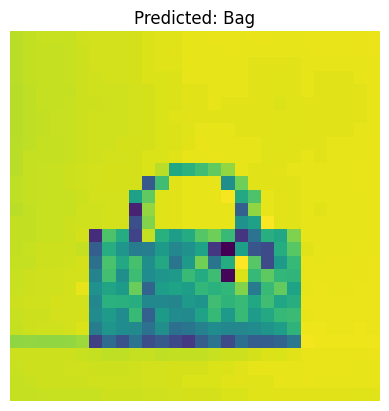

In [24]:
# fashion_minst class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Load and preprocess your image
img_path = "cnn image 1.jpg"   # 🔹 replace with your file path
img = image.load_img(img_path, target_size=(28, 28), color_mode='grayscale')
img_array = image.img_to_array(img) / 255.0            # normalize
img_array = np.expand_dims(img_array, axis=0)          # add batch dimension

# Predict
pred = model.predict(img_array)
pred_class = np.argmax(pred)
pred_prob = pred.flatten()  
# Create a table of probabilities
prob_table = pd.DataFrame({
    "Class": class_names,
    "Probability": pred_prob
}).sort_values(by="Probability", ascending=False)

print(prob_table)


# Show image and prediction
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {class_names[pred_class]}")
plt.show()


### Handling Images Not Belonging to Known Classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
         Class  Probability
0  T-shirt/top     0.918633
3        Dress     0.030782
2     Pullover     0.025602
6        Shirt     0.011402
8          Bag     0.011384
1      Trouser     0.001161
4         Coat     0.000810
5       Sandal     0.000128
9   Ankle boot     0.000092
7      Sneaker     0.000005


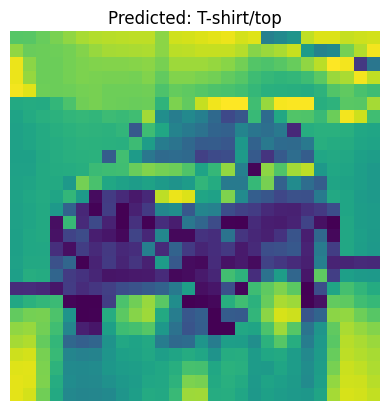

In [25]:
# Load and preprocess your image
img_path = "cnn image 2.jpg"   # 🔹 replace with your file path
img = image.load_img(img_path, target_size=(28, 28), color_mode='grayscale')
img_array = image.img_to_array(img) / 255.0            # normalize
img_array = np.expand_dims(img_array, axis=0)          # add batch dimension

# Predict
pred = model.predict(img_array)
pred_class = np.argmax(pred)
pred_prob = pred.flatten()  
# Create a table of probabilities
prob_table = pd.DataFrame({
    "Class": class_names,
    "Probability": pred_prob
}).sort_values(by="Probability", ascending=False)

print(prob_table)


# Show image and prediction
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {class_names[pred_class]}")
plt.show()